Question 1

In [38]:
import pandas as pd

# To load the dataset
df = pd.read_excel(r"F:\Semester 4\Machine Learning\CIA 1\QP_Data_road_accident_dataset_with_missing.xlsx")

# Showing first 10 rows
print(df.head(10))

# To separate numerical and categorical variables
num_vars = df.select_dtypes(include=['int64','float64']).columns
cat_vars = df.select_dtypes(include=['object']).columns

print("\nNumerical Variables:", list(num_vars))
print("Categorical Variables:", list(cat_vars))

# To check data types of all columns
print("\nData Types:\n", df.dtypes)


  Country  Year     Month Day of Week Time of Day Urban/Rural  Road Type  \
0     USA  2002   October     Tuesday     Evening       Rural     Street   
1      UK  2014  December    Saturday     Evening       Urban     Street   
2     USA  2012      July      Sunday   Afternoon       Urban    Highway   
3      UK  2017       May    Saturday     Evening       Urban  Main Road   
4  Canada  2002      July     Tuesday   Afternoon       Rural    Highway   
5   India  2010       May      Monday     Evening       Urban     Street   
6   China  2010     March      Monday   Afternoon       Rural     Street   
7     USA  2016      July      Friday   Afternoon       Rural  Main Road   
8   Japan  2014    August    Thursday   Afternoon       Rural    Highway   
9     USA  2007     April      Monday     Evening       Urban    Highway   

  Weather Conditions  Visibility Level  Number of Vehicles Involved  ...  \
0              Windy               NaN                            1  ...   
1          

C:\Users\dell\AppData\Local\Temp\ipykernel_56908\227936333.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_vars = df.select_dtypes(include=['object']).columns


Question 2a

In [40]:
df.describe()

,Year,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Driver Fatigue,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Insurance Claims,Medical Cost,Economic Loss,Population Density
count,132000.000000,125400.000000,132000.000000,132000.000000,104893.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,118824.000000,125400.000000,132000.000000,106979.000000,118800.000000,125400.000000
mean,2011.973348,275.104755,2.501227,74.544068,0.110463,0.500576,1.000773,0.998356,9.508205,1.995439,32.486666,5039.695672,4.495621,22999.326535,46028.388017,2505.985119
std,7.198624,129.946180,1.117272,26.001448,0.066818,0.500002,0.816304,0.817764,5.774366,1.412974,15.900793,2861.300571,2.867347,13309.840366,26642.146034,1441.036753
min,2000.000000,50.001928,1.000000,30.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,5.000177,100.062626,0.000000,500.110091,1000.335085,10.002669
25%,2006.000000,162.422604,2.000000,52.000000,0.053893,0.000000,0.000000,0.000000,5.000000,1.000000,18.694200,2554.836546,2.000000,11594.699610,23253.528405,1257.505421
50%,2012.000000,274.808977,3.000000,74.000000,0.107667,1.000000,1.000000,1.000000,9.000000,2.000000,32.549514,5033.213155,4.000000,22687.634120,45484.381415,2504.196516
75%,2018.000000,388.070736,3.000000,97.000000,0.161436,1.000000,2.000000,2.000000,15.000000,3.000000,46.288919,7523.931508,7.000000,33869.677745,67731.981662,3757.099191
max,2024.000000,499.999646,4.000000,119.000000,0.249989,1.000000,2.000000,2.000000,19.000000,4.000000,59.999588,9999.997468,9.000000,49999.930130,99999.622970,4999.991745


In [ ]:
# To identify variable with highest variation (we are using standard deviation)
variation = df[num_vars].std().sort_values(ascending=False)
print("Highest variation:", variation.index[0])

Highest variation: Economic Loss


Question 2b

In [ ]:

mean_medical = df['Medical Cost'].mean()
median_medical = df['Medical Cost'].median()

print("Mean:", mean_medical)
print("Median:", median_medical)

if mean_medical > median_medical:
    print("Right-skewed distribution (positive skew)")
elif mean_medical < median_medical:
    print("Left-skewed distribution (negative skew)")
else:
    print("Symmetric distribution")


Mean: 22999.326534801297
Median: 22687.63412
Right-skewed distribution (positive skew)


Question 3a

In [10]:
# To count missing values and percentage for each column
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({'Missing': missing, 'Percent': missing_percent})


,Missing,Percent
Country,0,0.000000
Year,0,0.000000
Month,0,0.000000
Day of Week,0,0.000000
Time of Day,0,0.000000
Urban/Rural,0,0.000000
Road Type,0,0.000000
Weather Conditions,0,0.000000
Visibility Level,6600,5.000000
Number of Vehicles Involved,0,0.000000


Question 3b

In [55]:
df['Visibility Level'] = df['Visibility Level'].fillna(df['Visibility Level'].median())
df['Traffic Volume'] = df['Traffic Volume'].fillna(df['Traffic Volume'].median())
df['Population Density'] = df['Population Density'].fillna(df['Population Density'].median())

Question 3c

In [56]:
df['Driver Alcohol Level'] = df['Driver Alcohol Level'].fillna(0)
df['Emergency Response Time'] = df['Emergency Response Time'].fillna(df['Emergency Response Time'].median())
df['Medical Cost'] = df['Medical Cost'].fillna(df['Medical Cost'].median())

Question 3d
Driver Alcohol Level may be MAR because alcohol tests might not be conducted in some regions or hospitals due to operational reasons. In this case, the missing value depends on external factors such as location or reporting practices.

Driver Alcohol Level may also be MNAR because drivers with higher alcohol consumption may refuse testing or leave the accident scene. Here, the missingness is directly related to the alcohol level itself.

question 4a

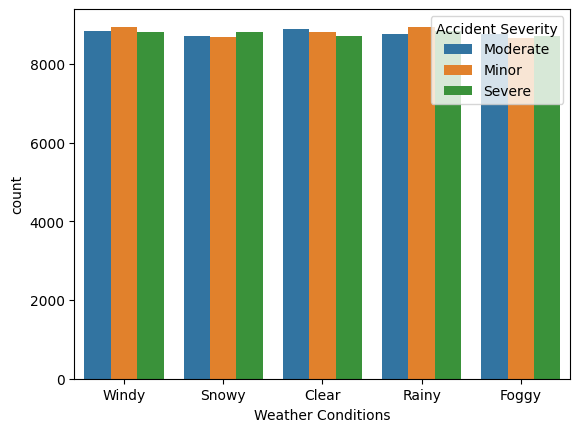

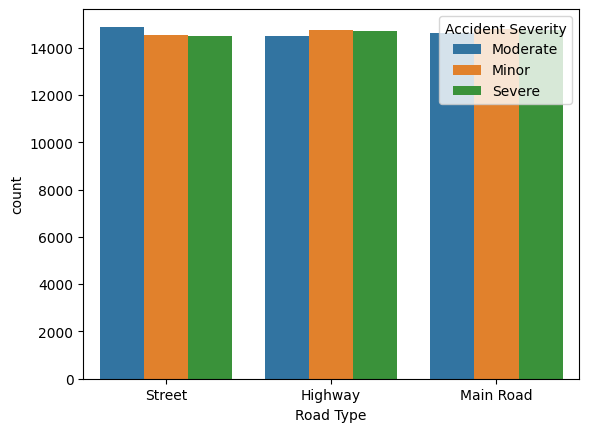

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x="Weather Conditions", hue="Accident Severity")
plt.show()
sns.countplot(data=df, x="Road Type", hue="Accident Severity")
plt.show()

Question 4b

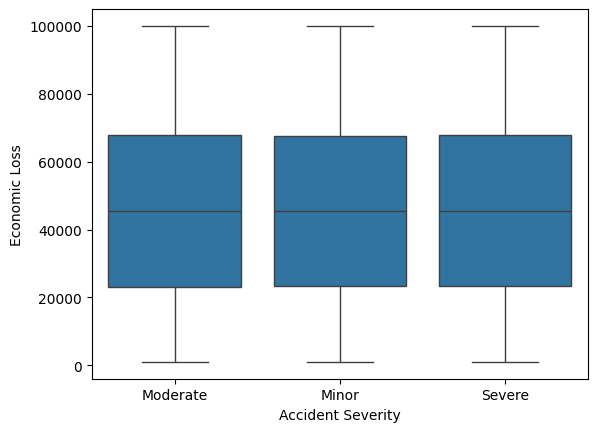

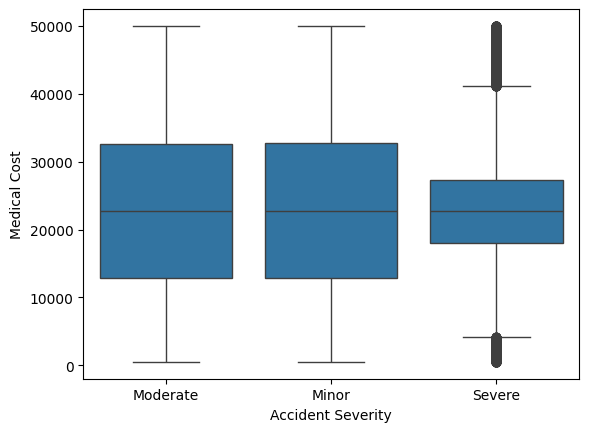

In [58]:
sns.boxplot(data=df, x="Accident Severity", y="Economic Loss")
plt.show()
sns.boxplot(data=df, x="Accident Severity", y="Medical Cost")
plt.show()

Question 4c

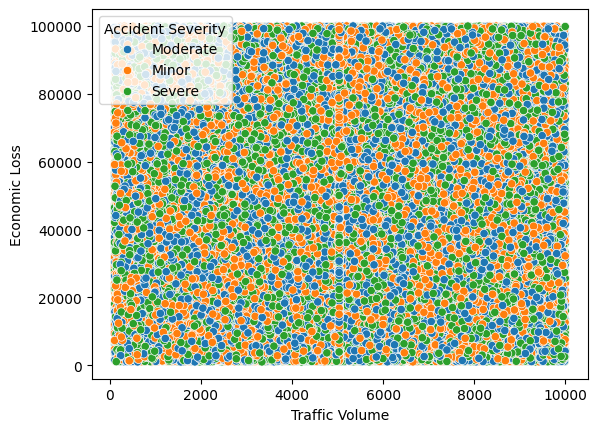

In [59]:
sns.scatterplot(data=df, x="Traffic Volume", y="Economic Loss", hue="Accident Severity")
plt.show()

Question 4d (Box Plot)

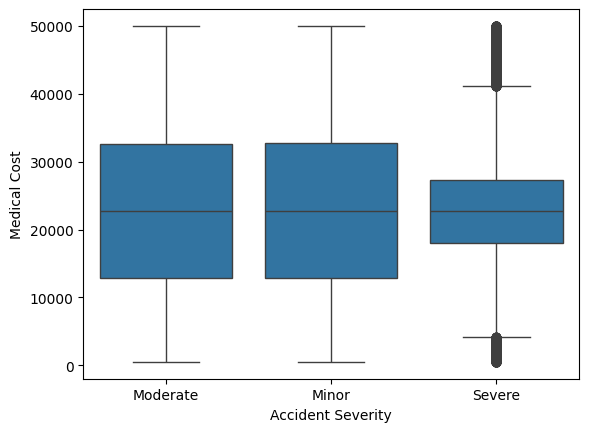

In [60]:
sns.boxplot(data=df, x="Accident Severity", y="Medical Cost")
plt.show()

Question 5

                                 Year  Visibility Level  \
Year                         1.000000          0.002552   
Visibility Level             0.002552          1.000000   
Number of Vehicles Involved -0.003528          0.000816   
Speed Limit                 -0.002744         -0.002049   
Driver Alcohol Level         0.000554          0.004305   
Driver Fatigue               0.000545          0.002185   
Pedestrians Involved        -0.002093         -0.004019   
Cyclists Involved           -0.000077         -0.000089   
Number of Injuries           0.001120          0.000434   
Number of Fatalities        -0.004965         -0.001022   
Emergency Response Time     -0.001566         -0.000918   
Traffic Volume              -0.000343         -0.003100   
Insurance Claims             0.001109          0.004462   
Medical Cost                -0.006863          0.002647   
Economic Loss               -0.004264          0.003311   
Population Density           0.003751         -0.000308 

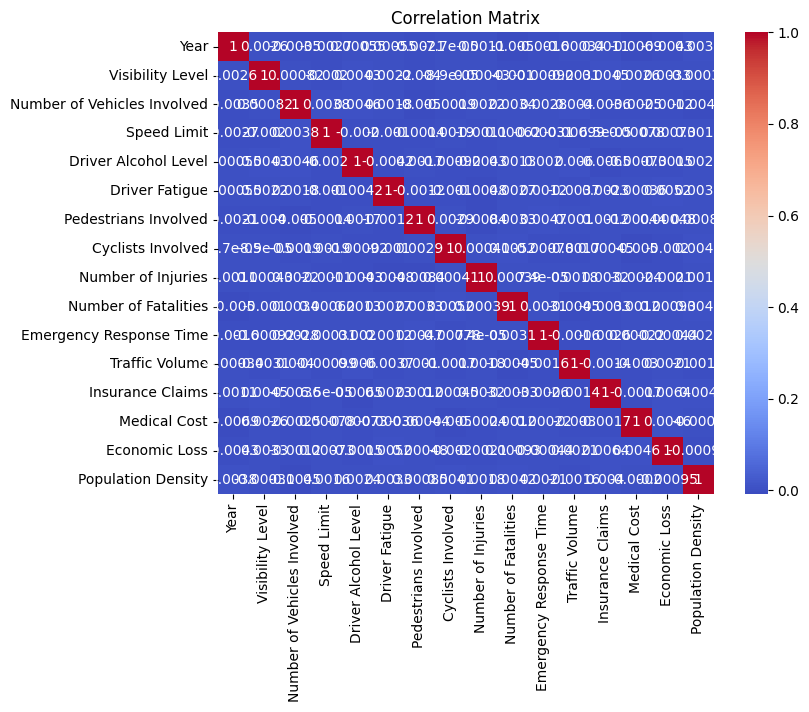

In [61]:
corr = df[num_vars].corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Question 6a

In [ ]:
# finding Outlier using IQR method
for col in ['Medical Cost','Economic Loss','Traffic Volume','Emergency Response Time']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: Outliers count = {len(outliers)}")


Medical Cost: Outliers count = 0
Economic Loss: Outliers count = 0
Traffic Volume: Outliers count = 0
Emergency Response Time: Outliers count = 0


Question 6b

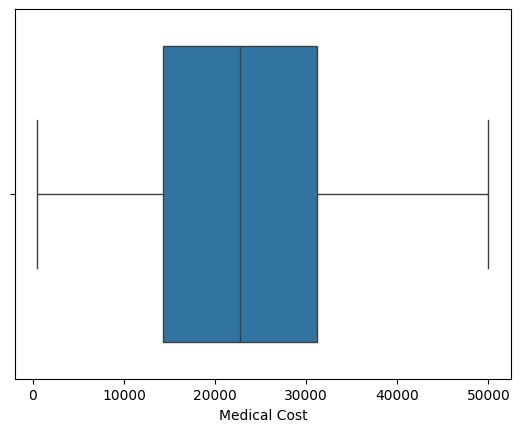

In [63]:
df['Medical Cost'].sort_values(ascending=False).head(10)
sns.boxplot(x=df['Medical Cost'])
plt.show()

Question 7a

C:\Users\dell\AppData\Local\Temp\ipykernel_56908\4128321797.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Year'].astype(str) + " " + df['Month'], errors='coerce')


<Axes: title={'center': 'Accidents Over Time'}, xlabel='Date'>

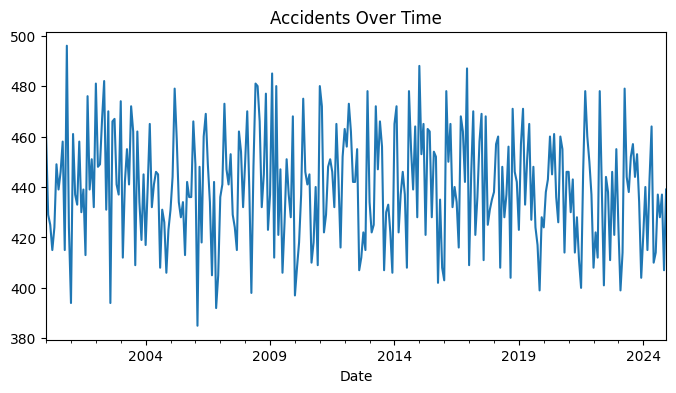

In [ ]:
# Creating a Date column from Year + Month
df['Date'] = pd.to_datetime(df['Year'].astype(str) + " " + df['Month'], errors='coerce')

# To count accidents per month
accidents_over_time = df.groupby(df['Date'].dt.to_period("M")).size()

# Plot
accidents_over_time.plot(kind='line', figsize=(8,4), title="Accidents Over Time")


Question 7b

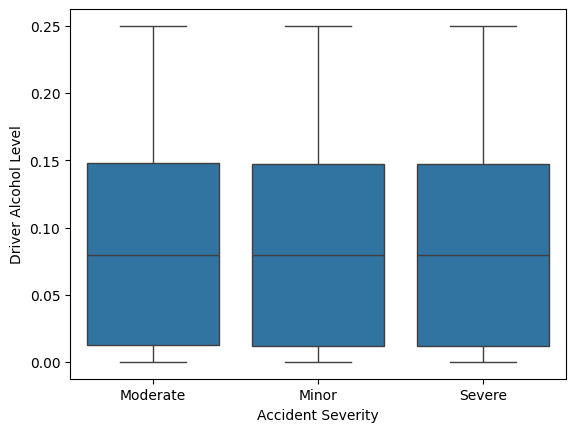

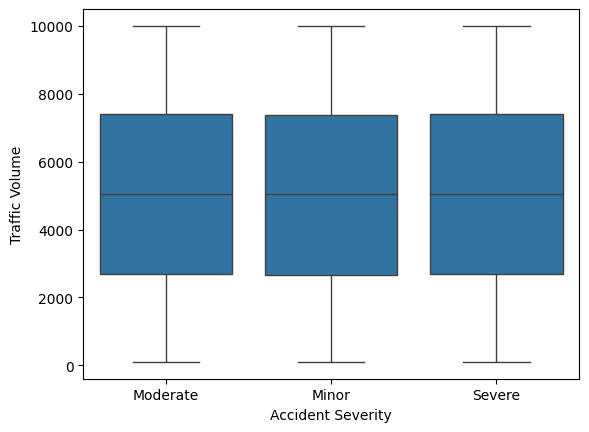

In [65]:
sns.boxplot(data=df, x="Accident Severity", y="Driver Alcohol Level")
plt.show()
sns.boxplot(data=df, x="Accident Severity", y="Traffic Volume")
plt.show()

Question 7c

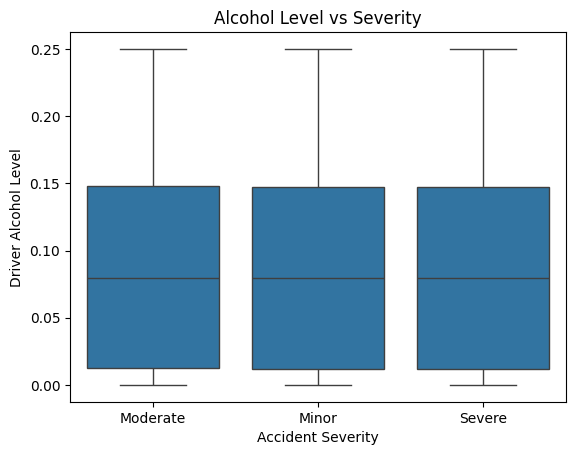

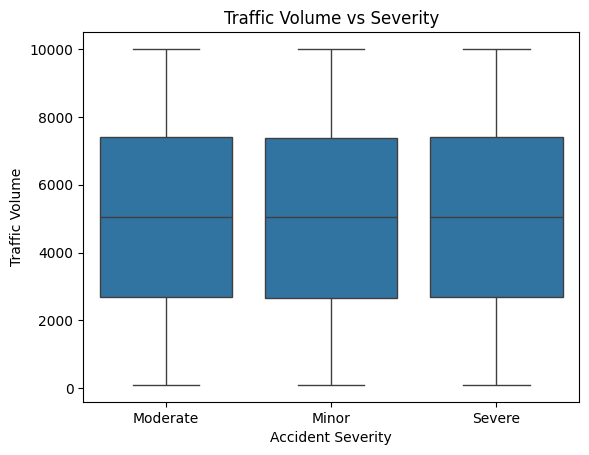

In [66]:
sns.boxplot(data=df, x="Accident Severity", y="Driver Alcohol Level")
plt.title("Alcohol Level vs Severity")
plt.show()

sns.boxplot(data=df, x="Accident Severity", y="Traffic Volume")
plt.title("Traffic Volume vs Severity")
plt.show()

Question 7d

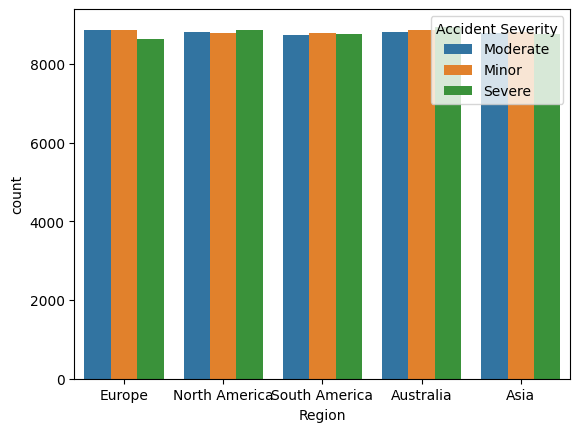

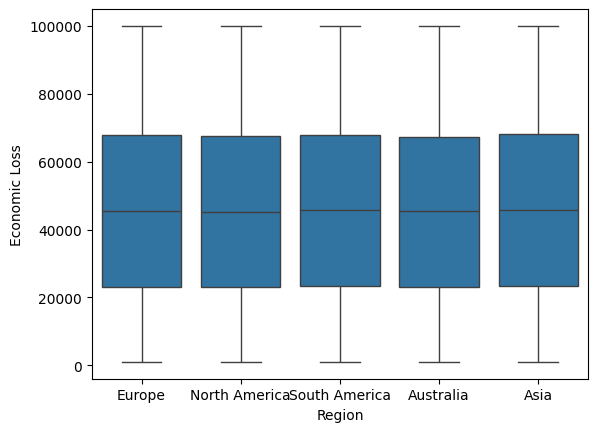

In [67]:
sns.countplot(data=df, x="Region", hue="Accident Severity")
plt.show()
sns.boxplot(data=df, x="Region", y="Economic Loss")
plt.show()